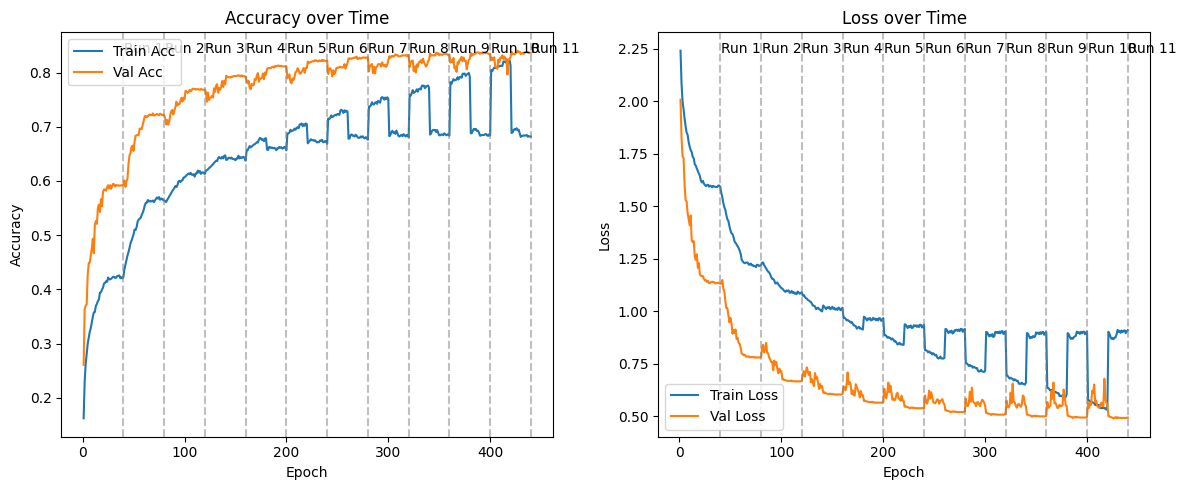

In [15]:
import re
import glob
import matplotlib.pyplot as plt

import os
# print(os.listdir('./'))
log_files = []
for folder in os.listdir('.'):
    if not os.path.isdir(folder):
        continue
    if not 'default' in folder:
        continue
    log_files.append(folder)
    

# storage
all_epochs = []
train_acc = []
val_acc = []
train_loss = []
val_loss = []

epoch_offset = 0

# regex pattern
pattern = re.compile(
    r"\[(\d+)/\d+\].*?Train Acc: ([\d.]+) \| Val Acc: ([\d.]+) \| Train Loss: ([\d.]+) \| Val Loss: ([\d.]+)"
)

file_boundaries = []

# === PARSE FILES ===
for folder in log_files:
    file = os.path.join(folder, 'log', 'result_log.txt')
    with open(file, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                epoch = int(match.group(1)) + epoch_offset
                all_epochs.append(epoch)
                train_acc.append(float(match.group(2)))
                val_acc.append(float(match.group(3)))
                train_loss.append(float(match.group(4)))
                val_loss.append(float(match.group(5)))

    # update offset so next file continues epochs
    epoch_offset = max(all_epochs)
    
    # 記錄這個檔案的結尾位置
    file_boundaries.append(epoch_offset)
# === PLOT ===
plt.figure(figsize=(12, 5))

# Accuracy subplot
plt.subplot(1, 2, 1)
plt.plot(all_epochs, train_acc, label="Train Acc")
plt.plot(all_epochs, val_acc, label="Val Acc")
for i, boundary in enumerate(file_boundaries):
    plt.axvline(x=boundary, color='gray', linestyle='--', alpha=0.5)
    plt.text(boundary + 0.5, plt.ylim()[1] * 0.98, f'Run {i+1}', 
             rotation=0, verticalalignment='top')


plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Time")
plt.legend()
# plt.grid()

# Loss subplot
plt.subplot(1, 2, 2)
plt.plot(all_epochs, train_loss, label="Train Loss")
plt.plot(all_epochs, val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Time")
plt.legend()
# plt.grid()
for i, boundary in enumerate(file_boundaries):
    plt.axvline(x=boundary, color='gray', linestyle='--', alpha=0.5)
    plt.text(boundary + 0.5, plt.ylim()[1] * 0.98, f'Run {i+1}', 
             rotation=0, verticalalignment='top')
plt.tight_layout()
plt.savefig("training_curves.png", dpi=300)
plt.show()